# Import Libraries

In [1]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

# Loading CAR Data

In [21]:
# data path (NOTE: CHANGE THIS DEPENDING ON THE PARTICULAR PATH WHERE YOU STORE THE CAR DATA)
data_path = "/Users/willkrew/Desktop/Classes/STAT_390/Data/"

folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [23]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [26]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

# Checking the datatype of all the columns
df_main.dtypes


# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

# Filtering data for relevant rows / time difference columns

In [99]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous menu and seconds to next menu within each Contact Session ID) ---

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# a) Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)

# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column


# Defining new columns

- Call_successful: caller reaches a queue
- Num_visits: number of times a caller visits a particular menu (in this case LegalMenu2)
- After_first_LegalMenu2_activity: The menu (if any) visited directly after the first visit to LegalMenu2
- First_LegalMenu2_seconds_until_next: The time (seconds) spent during the first visit to LegalMenu2

In [100]:
g = df_filt.groupby('Contact Session ID')

# contains 'queue' in Activity Name (case-insensitive)
queue_hit = df_filt['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
# Queue Name is not null
queue_present = df_filt['Queue Name'].notna()
# Call_successful = 1 if either condition occurs anywhere in the session
df_filt['Call_successful'] = (
    (queue_hit | queue_present)
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 2) Num_visits: count of rows with Activity Name exactly 'LegalMenu2' within the session
legal_mask = df_filt['Activity Name'].eq('LegalMenu2')
df_filt['Num_visits'] = (
    legal_mask.groupby(df_filt['Contact Session ID'])
              .transform('sum')
)

# Helper: next Activity Name within session (row-wise shift)
df_filt['_next_activity_in_session'] = g['Activity Name'].shift(-1)

# 3) Identify the FIRST 'LegalMenu2' row per session
#    (cumulative count of True within group == 1)
cum_legal = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
first_legal_mask = legal_mask & (cum_legal == 1)

# 3a) After_first_LegalMenu2_activity: the Activity Name on the *next* row after the first LegalMenu2 (per session), broadcast to the rows of that Contact Session ID
first_legal_next_activity_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_first_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(first_legal_next_activity_by_session)

# 4) First_LegalMenu2_seconds_until_next: seconds_until_next on that first LegalMenu2 row (per session), broadcast to all rows
first_legal_wait_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', 'seconds_until_next']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['seconds_until_next']
)
df_filt['First_LegalMenu2_seconds_until_next'] = df_filt['Contact Session ID'].map(first_legal_wait_by_session)

# Drop helper column
df_filt.drop(columns=['_next_activity_in_session'], inplace=True)


# Number of total visits to legal menu by first submenu visited

- num_visits_by_key is absolute counts
- num_visits_by_key_pct are the percentages
- num_visits_by_key_pct_withN includes percentages as well as total count of each submenu

In [122]:

# --- 0) Build session-level table and key mapping ----------------------------
session_df = (
    df_filt[['Contact Session ID',
             'After_first_LegalMenu2_activity',
             'Num_visits',
             'First_LegalMenu2_seconds_until_next']]
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

def _to_key(activity):
    if pd.isna(activity):
        return 'NoNextMenu'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

session_df['After_first_key'] = session_df['After_first_LegalMenu2_activity'].map(_to_key)

# One-to-one mapping from key -> submenu label(s)
key_to_submenus = {
    '1':  'HIVMenu',
    '2':  'FamilyMenu',
    '3':  'HousingMenu',
    '4':  'BenefitsMenu',
    '5':  'GetLoggedInConsumerAgents | GetLoggedInConsumerSPAgents',
    '6':  'CriminalRecordsVoicemailTransfer',
    '7':  'EmploymentMenu',
    '8':  'ImmigrationMenu',
    '9':  'GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents',
    '10': 'OtherLegalMenu',
    '#':  'LegalMenu2',
    '*':  'FrontDeskTransfer | HolidayPrompt',
    'NoNextMenu': '—',
    'Unknown':    '—',
}
ordered_keys = ['1','2','3','4','5','6','7','8','9','10','#','*','NoNextMenu','Unknown']

# --- 1) Num_visits distribution by key (exclude NoNextMenu, Unknown) --------
valid_mask = ~session_df['After_first_key'].isin(['NoNextMenu', 'Unknown'])
session_valid = session_df[valid_mask].copy()

# Counts
num_visits_by_key = pd.crosstab(
    session_valid['After_first_key'],
    session_valid['Num_visits'],
    dropna=False
)

# Add Submenus, order rows, drop excluded keys (already excluded), add Total row
num_visits_by_key.insert(
    0, 'Submenus',
    num_visits_by_key.index.map(lambda k: key_to_submenus.get(k, '—'))
)
num_visits_by_key = num_visits_by_key.reindex(ordered_keys, fill_value=0)
num_visits_by_key = num_visits_by_key.loc[~num_visits_by_key.index.isin(['NoNextMenu','Unknown'])]

total_row_counts = pd.DataFrame(num_visits_by_key.drop(columns='Submenus').sum()).T
total_row_counts.index = ['Total']
total_row_counts.insert(0, 'Submenus', '—')
num_visits_by_key = pd.concat([num_visits_by_key, total_row_counts], axis=0)

# Row-normalized percentages
num_cols_nv = [c for c in num_visits_by_key.columns if c != 'Submenus']
row_sums_nv = num_visits_by_key[num_cols_nv].sum(axis=1).replace(0, np.nan)
num_visits_by_key_pct = num_visits_by_key.copy()
num_visits_by_key_pct[num_cols_nv] = (
    num_visits_by_key_pct[num_cols_nv].div(row_sums_nv, axis=0)
).round(3)

# ---> Add N to the right of the pct table
row_N_nv = num_visits_by_key[num_cols_nv].sum(axis=1).astype('Int64')
num_visits_by_key_pct_withN = num_visits_by_key_pct.copy()
num_visits_by_key_pct_withN['N'] = row_N_nv

In [192]:
num_visits_by_key

Num_visits,Submenus,1,2,3,4,5,6,7,8,9,...,11,12,13,15,18,19,20,21,62,N
1,HIVMenu,0.769,0.174,0.044,0.007,0.002,0.003,0.002,0.001,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1768
2,FamilyMenu,0.904,0.070,0.017,0.006,0.002,0.001,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22774
3,HousingMenu,0.849,0.111,0.025,0.010,0.003,0.001,0.001,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17135
4,BenefitsMenu,0.977,0.019,0.003,0.001,0.000,0.000,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6727
5,GetLoggedInConsumerAgents | GetLoggedInConsume...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1082
6,CriminalRecordsVoicemailTransfer,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1951
7,EmploymentMenu,0.972,0.023,0.003,0.001,0.000,0.000,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4388
8,ImmigrationMenu,0.969,0.026,0.003,0.002,0.000,0.000,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3407
9,GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,136
10,OtherLegalMenu,0.851,0.116,0.021,0.007,0.003,0.001,0.000,0.000,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12495


# % Reaching Right Menu (not going back to legal menu) by submenu and whether caller listens to the full prompt

- right_by_key_wait: absolute counts
- right_by_key_wait_pct_withN: percentages, with total count for each sub menu / 'full prompt?' combo

In [119]:
# --- 2) Right vs Not-right by key × wait bucket (<=120 / >120 / Unknown) ----
session_df['Right_menu'] = np.where(session_df['Num_visits'].eq(1), 'Right', 'Not right')
session_df['Wait120_bucket'] = np.where(
    session_df['First_LegalMenu2_seconds_until_next'].isna(), 'Unknown',
    np.where(session_df['First_LegalMenu2_seconds_until_next'] <= 120, '<=120', '>120')
)

# Exclude NoNextMenu / Unknown keys
session_valid2 = session_df[~session_df['After_first_key'].isin(['NoNextMenu','Unknown'])].copy()

# Base counts by (key × wait bucket)
right_by_key_wait = pd.crosstab(
    [session_valid2['After_first_key'], session_valid2['Wait120_bucket']],
    session_valid2['Right_menu'],
    dropna=False
).sort_index()

# Insert Submenus as a leading column
right_by_key_wait.insert(
    0, 'Submenus',
    [ key_to_submenus.get(k, '—') for k, _w in right_by_key_wait.index ]
)

# ---- Add TOTAL rows: per-bucket and grand (exclude Unknown wait bucket) ----
cols_rnw = [c for c in right_by_key_wait.columns if c != 'Submenus']

def _total_row_for_bucket(df, bucket_label):
    mask = df.index.get_level_values(1) == bucket_label
    s = df.loc[mask, cols_rnw].sum()
    out = pd.DataFrame([s], index=pd.MultiIndex.from_tuples([('Total', bucket_label)],
                                                            names=df.index.names))
    out.insert(0, 'Submenus', '—')
    return out

# Totals for <=120 and >120 separately
total_le  = _total_row_for_bucket(right_by_key_wait, '<=120')
total_gt  = _total_row_for_bucket(right_by_key_wait, '>120')

# Grand total combining the two subcategories (ignoring 'Unknown')
mask_both = right_by_key_wait.index.get_level_values(1).isin(['<=120','>120'])
grand_sum = right_by_key_wait.loc[mask_both, cols_rnw].sum()
total_all = pd.DataFrame([grand_sum],
                         index=pd.MultiIndex.from_tuples([('Total','All')],
                                                         names=right_by_key_wait.index.names))
total_all.insert(0, 'Submenus', '—')

# Append the total rows
right_by_key_wait = pd.concat([right_by_key_wait, total_le, total_gt, total_all], axis=0)

# ---- Percentage version (row-normalized), plus N on the right --------------
row_sums_rnw = right_by_key_wait[cols_rnw].sum(axis=1).replace(0, np.nan)
right_by_key_wait_pct = right_by_key_wait.copy()
right_by_key_wait_pct[cols_rnw] = (
    right_by_key_wait_pct[cols_rnw].div(row_sums_rnw, axis=0)
).round(3)

# Add N to the right (raw row totals)
right_by_key_wait_pct_withN = right_by_key_wait_pct.copy()
right_by_key_wait_pct_withN['N'] = right_by_key_wait[cols_rnw].sum(axis=1).astype('Int64')

# ---- Optional: order the MultiIndex rows by key order -----------------------
def _sort_multiindex_by_key(df, key_order):
    if not isinstance(df.index, pd.MultiIndex):
        return df
    lvl0 = df.index.get_level_values(0)
    order_map = {k:i for i,k in enumerate(key_order)}
    # Put 'Total' after the keyed rows
    order_map.setdefault('Total', len(order_map)+1)
    idx_order = np.argsort([order_map.get(k, 1_000_000) for k in lvl0])
    return df.iloc[idx_order]

right_by_key_wait                 = _sort_multiindex_by_key(right_by_key_wait, ordered_keys)
right_by_key_wait_pct_withN       = _sort_multiindex_by_key(right_by_key_wait_pct_withN, ordered_keys)


In [136]:
right_by_key_wait

Right_menu                                                               Submenus  \
After_first_key Wait120_bucket                                                      
1               <=120                                                     HIVMenu   
                >120                                                      HIVMenu   
2               >120                                                   FamilyMenu   
                <=120                                                  FamilyMenu   
3               >120                                                  HousingMenu   
                <=120                                                 HousingMenu   
4               <=120                                                BenefitsMenu   
                >120                                                 BenefitsMenu   
5               <=120           GetLoggedInConsumerAgents | GetLoggedInConsume...   
                >120            GetLoggedInConsumerAgents | GetLoggedInConsume...   
6               <=120                            CriminalRecordsVoicemailTransfer   
                >120                             CriminalRecordsVoicemailTransfer   
7               <=120                                              EmploymentMenu   
                >120                                               EmploymentMenu   
8               >120                                              ImmigrationMenu   
                <=120                                             ImmigrationMenu   
9               <=120           GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents   
                >120            GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents   
10              <=120                                              OtherLegalMenu   
                >120                                               OtherLegalMenu   
#               <=120                                                  LegalMenu2   
                >120                                                   LegalMenu2   
*               >120                            FrontDeskTransfer | HolidayPrompt   
                <=120                           FrontDeskTransfer | HolidayPrompt   
Total           <=120                                                           —   
                >120                                                            —   
                All                                                             —   

Right_menu                      Not right  Right  
After_first_key Wait120_bucket                    
1               <=120                 305   1219  
                >120                  104    140  
2               >120                  333    894  
                <=120                1853  19694  
3               >120                  276    830  
                <=120                2310  13719  
4               <=120                 119   6013  
                >120                   38    557  
5               <=120                   0    997  
                >120                    0     85  
6               <=120                   0   1755  
                >120                    0    196  
7               <=120                  93   3745  
                >120                   30    520  
8               >120                   37    938  
                <=120                  70   2362  
9               <=120                   0     63  
                >120                    0     73  
10              <=120                  17    171  
                >120                 1849  10458  
#               <=120                2100      0  
                >120                 3260      0  
*               >120                    0     92  
                <=120                   0    237  
Total           <=120                6867  49975  
                >120                 5927  14783  
                All                 12794  64758

# % of callers reaching legal menu who have a 'successful call' (as defined by ulimately reaching a queue)

In [193]:
100*df_filt[lambda x: x.Num_visits>=1][lambda x: x.Call_successful == 1]['Contact Session ID'].nunique() / df_filt[lambda x: x.Num_visits>=1]['Contact Session ID'].nunique()

66.07836368343834

# Frequency Table for Number of Visits to Legal Menu

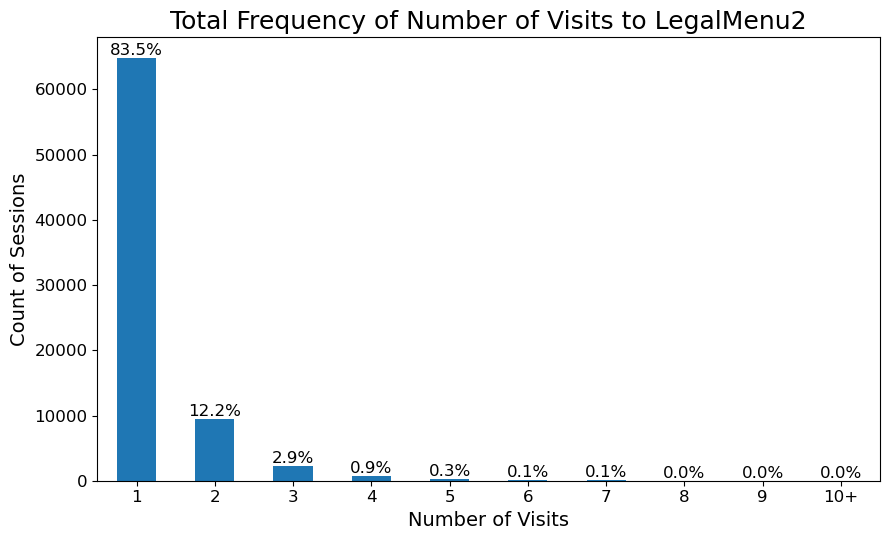

In [183]:
# 1) Pull totals across keys from the 'Total' row
totals = num_visits_by_key.drop(columns='Submenus', errors='ignore').loc['Total']

# 2) Group visits >= 10 into "10+"
counts = {}
for k, v in totals.items():
    try:
        n = int(k)
    except Exception:
        continue  # ignore any non-numeric columns
    key = '10+' if n >= 10 else n
    counts[key] = counts.get(key, 0) + int(v)

# 3) Order bins (numeric first, then "10+")
order = sorted([x for x in counts if x != '10+']) + (['10+'] if '10+' in counts else [])
agg_series = pd.Series(counts).reindex(order)

# 4) Plot counts, annotate percentages on bars (larger titles/fonts, upright x labels)
fig, ax = plt.subplots(figsize=(9, 5.5))
agg_series.plot(kind='bar', ax=ax)

ax.set_title("Total Frequency of Number of Visits to LegalMenu2", fontsize=18)
ax.set_xlabel("Number of Visits", fontsize=14)
ax.set_ylabel("Count of Sessions", fontsize=14)

# Make x-axis labels upright and centered
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

# Add % labels on bars
total_n = agg_series.sum()
for patch, val in zip(ax.patches, agg_series.values):
    pct = 100.0 * val / total_n if total_n else 0.0
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()


# Graphs

1. Percent reaching wrong menu by submenu
2. Percent reaching wrong menu by submenu (broken down by whether the caller lsitened to the full prompt)
3. Percent of callers listening to the full prompt by submenu chosen

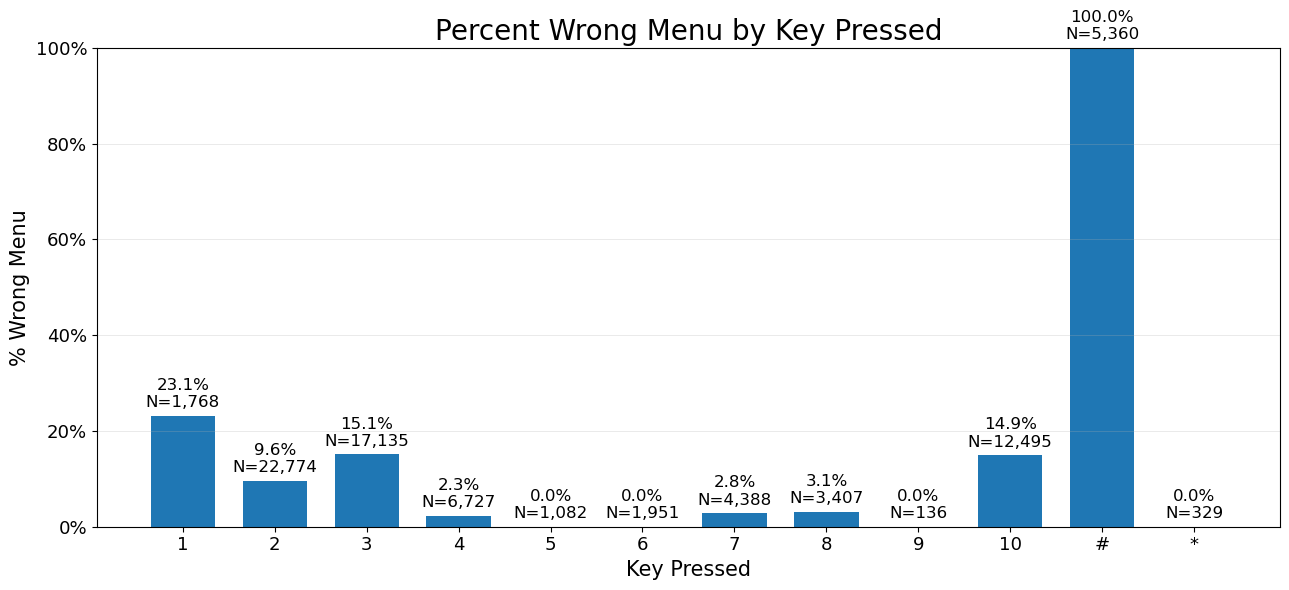

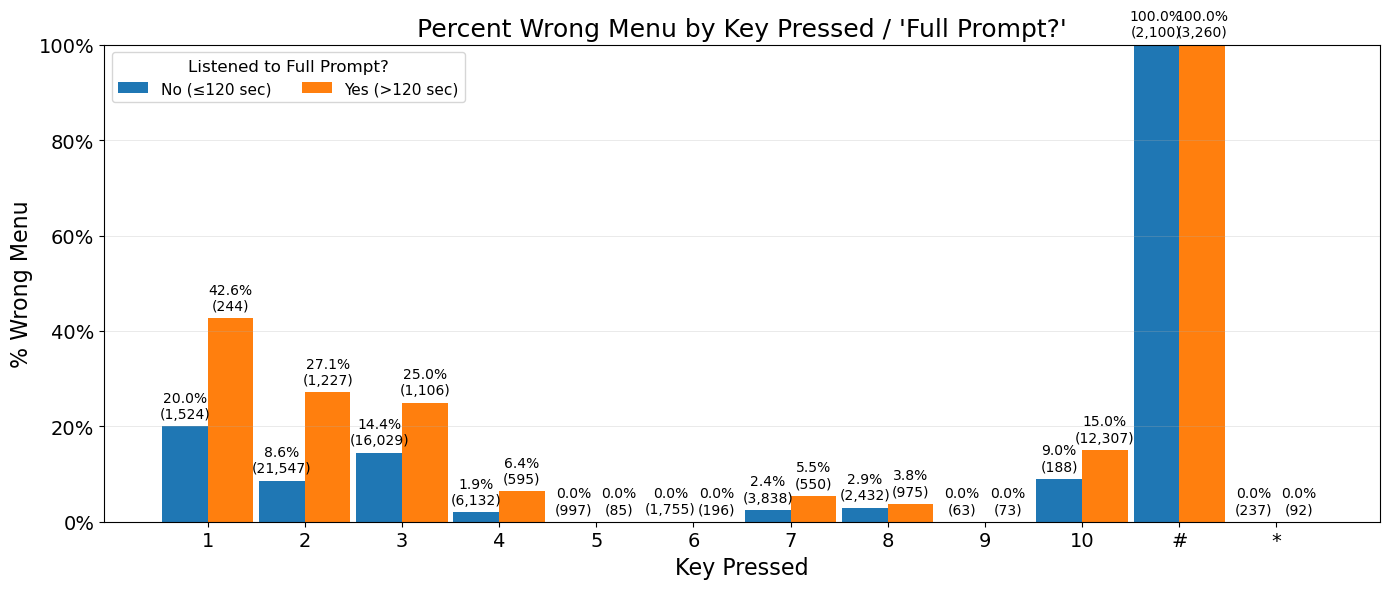

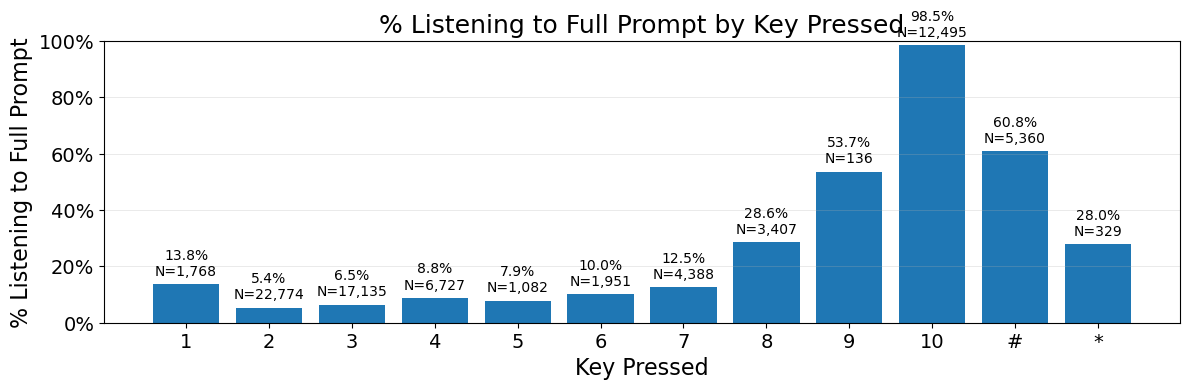

In [191]:

from matplotlib.ticker import PercentFormatter

# ---- Base prep (expects right_by_key_wait with MultiIndex rows: (After_first_key, Wait120_bucket)) ----
rbkw = right_by_key_wait.drop(columns='Submenus', errors='ignore').copy()

if not isinstance(rbkw.index, pd.MultiIndex) or rbkw.index.nlevels != 2:
    raise ValueError("right_by_key_wait must have a 2-level MultiIndex on rows: (After_first_key, Wait120_bucket)")

# Drop any 'Total' rows in level 0, keep only the two real buckets
rbkw = rbkw[rbkw.index.get_level_values(0) != 'Total']
valid_buckets = ['<=120', '>120']
rbkw = rbkw[rbkw.index.get_level_values(1).isin(valid_buckets)].copy()

key_name, bucket_name = rbkw.index.names
key_order = rbkw.index.get_level_values(0).unique().tolist()
x = np.arange(len(key_order))

# ==== 1) % Not right by key (collapsed over wait buckets) — stacked labels ====
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(x, collapsed['% Not right'].values, width=0.7)

ax.set_title("Percent Wrong Menu by Key Pressed", fontsize=20)
ax.set_xlabel("Key Pressed", fontsize=15)
ax.set_ylabel("% Wrong Menu", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in key_order], rotation=0, ha='center', fontsize=13)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)
ax.set_ylim(0, 100)

# STACKED bar labels (percent on top line, count on the next line)
labels = [f"{p:.1f}%\nN={n:,}" for p, n in zip(collapsed['% Not right'].values, collapsed['N'].values)]
ax.bar_label(bars, labels=labels, padding=4, fontsize=12)

plt.tight_layout()
plt.show()


from matplotlib.ticker import PercentFormatter

# ==== 2) Side-by-side % Not right for No (<=120) vs Yes (>120) — stacked labels ====

# Recompute per-bucket stats fresh (prevents stale/misaligned pct_* series)
_per = rbkw.copy()
_per['N'] = (_per['Right'] + _per['Not right']).astype(int)
_per['% Not right'] = (_per['Not right'] / _per['N'].replace(0, np.nan) * 100).fillna(0)

# Ensure both buckets exist for every key (align to the same order)
_per = _per.reindex(
    pd.MultiIndex.from_product([key_order, ['<=120', '>120']], names=[key_name, bucket_name]),
    fill_value=0
)

pct_no  = _per.xs('<=120', level=1)['% Not right'].reindex(key_order).fillna(0)
pct_yes = _per.xs('>120',  level=1)['% Not right'].reindex(key_order).fillna(0)
N_no    = _per.xs('<=120', level=1)['N'].reindex(key_order).fillna(0).astype(int)
N_yes   = _per.xs('>120',  level=1)['N'].reindex(key_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
width = 0.47
bars_no  = ax.bar(x - width/2, pct_no.values,  width, label="No (≤120 sec)")
bars_yes = ax.bar(x + width/2, pct_yes.values, width, label="Yes (>120 sec)")

ax.set_title("Percent Wrong Menu by Key Pressed / 'Full Prompt?'", fontsize=18)
ax.set_xlabel("Key Pressed", fontsize=16)
ax.set_ylabel("% Wrong Menu", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in key_order], rotation=0, ha='center', fontsize=14)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)
ax.set_ylim(0, 100)

# Legend with title
ax.legend(title="Listened to Full Prompt?", fontsize=11, title_fontsize=12, ncols=2, frameon=True)

# STACKED bar labels (percent on top line, count beneath)
labels_no  = [f"{p:.1f}%\n({int(n):,})" for p, n in zip(pct_no.values,  N_no.values)]
labels_yes = [f"{p:.1f}%\n({int(n):,})" for p, n in zip(pct_yes.values, N_yes.values)]
ax.bar_label(bars_no,  labels=labels_no,  padding=4, fontsize=10)
ax.bar_label(bars_yes, labels=labels_yes, padding=4, fontsize=10)

plt.tight_layout()
plt.show()


# === 3) Share listening to the full prompt (Yes = >120 sec) by After_first_key ===
# Uses rbkw (right_by_key_wait without 'Submenus'), key_order, x from earlier cells.

# Count sessions per (key, bucket), then pivot
bucket_counts = rbkw[['Right', 'Not right']].sum(axis=1).rename('N_bucket').reset_index()
bucket_counts = bucket_counts[bucket_counts[bucket_name].isin(['<=120','>120'])].copy()

pivot = bucket_counts.pivot_table(index=key_name,
                                  columns=bucket_name,
                                  values='N_bucket',
                                  aggfunc='sum',
                                  fill_value=0).reindex(key_order)

# Percent listening to full prompt = share in '>120'
row_sums = pivot.sum(axis=1).replace(0, np.nan)
pct_yes  = (pivot['>120'] / row_sums * 100).fillna(0)
N_total  = row_sums.fillna(0).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(x, pct_yes.values, width=0.8, label="Yes (>120 sec)")

ax.set_title("% Listening to Full Prompt by Key Pressed", fontsize=18)
ax.set_xlabel("Key Pressed", fontsize=16)
ax.set_ylabel("% Listening to Full Prompt", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in key_order], rotation=0, ha='center', fontsize=14)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)
ax.set_ylim(0, 100)

# Labels: percent on top line, total N beneath
labels = [f"{p:.1f}%\nN={n:,}" for p, n in zip(pct_yes.values, N_total.values)]
ax.bar_label(bars, labels=labels, padding=4, fontsize=10)

plt.tight_layout()
plt.show()